<a href="https://colab.research.google.com/github/va4756/deeplearn_practice/blob/main/pytorch_reinfoceL_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1.FSDP1(Fully Sharded Data Parallel)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import files
file_uploaded = files.upload()

In [ ]:
# PyTorch versions 1.12
import os
import argparse
import functools
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms

from torch.optim.lr_scheduler import StepLR

import torch.distributed as dist
import torch.multiprocessing as mp
from torch.nn.parallel import DistributedDataParallel as DDP
from torch.utils.data.distributed import DistributedSampler
from torch.distributed.fsdp import FullyShardedDataParallel as FSDP
from torch.distributed.fsdp.fully_sharded_data_parallel import (
    CPUOffload, BackwardPrefetch
)
from torch.distributed.fsdp.wrap import (
    size_based_auto_wrap_policy, enable_wrap, wrap
)

In [ ]:
def setup(rank, world_size):
    os.environ['MASTER_ADDR'] = 'localhost'
    os.environ['MASTER_PORT'] = '12355'

    dist.init_process_group("nccl", rank=rank, world_size=world_size)

def cleanup():
    dist.destroy_process_group()

In [ ]:
# Define toy model for handwritten digit classification.
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x= self.dropout2(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)
        return output

In [ ]:
# Define a train function
def train(args, model, rank, world_size, train_loader, optimizer, epoch, sampler=None):
    model.train()
    ddp_loss = torch.zeros(2).to(rank)
    if sampler:
        sampler.set_epoch(epoch)
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(rank), target.to(rank)
        optimizer.zero_grad()
        output = model(data)
        loss = F.nll_loss(output, target, reduction='sum')
        loss.backward()
        optimizer.step()
        ddp_loss[0] += loss.item()
        ddp_loss[1] += len(data)

    dist.all_reduce(ddp_loss, op=dist.ReduceOp.SUM)
    if rank == 0:
        print('Train Epoch: {} \tLoss" {:.6f}'.format(epoch, ddp_loss[0] / ddp_loss[1]))

In [ ]:
# Define a validation function
def test(model, rank, world_size, test_loader):
    model.eval()
    correct = 0
    ddp_loss = torch.zeros(3).to(rank)
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(rank), target.to(rank)
            output = model(data)
            ddp_loss[0] += F.nll_loss(output, target, reduction='sum').item()
            pred = output.argmax(dim=1, keepdim=True)
            ddp_loss[1] += pred.eq(target.view_as(pred)).sum().item()
            ddp_loss[2] += len(data)

    dist.all_reduce(ddp_loss, op=dist.ReduceOp.SUM)

    if rank == 0:
        test_loss = ddp_loss[0] / ddp_loss[2]
        print('Test set: Average loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)\n'.format(
            test_loss, int(ddp_loss[1]), int(ddp_loss[2]),
            100. * ddp_loss[1] / ddp_loss[2]))

In [ ]:
# Define a distributed train function that wraps the model in FSDP
def fsdp_main(rank, world_size, args):
    setup(rank, world_size)

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))
    ])

    dataset1 = datasets.MNIST('../data', train=True, download=True, transform=transform)
    dataset2 = datasets.MNIST('../data', train=False, transform=transform)

    sampler1 = DistributedSampler(dataset1, rank=rank, num_replicas=world_size, shuffle=True)
    sampler2 = DistributedSampler(dataset2, rank=rank, num_replicas=world_size)

    train_kwargs = {'batch_size': args.batch_size, 'sampler': sampler1}
    test_kwargs = {'batch_size': args.test_batch_size, 'sampler': sampler2}
    cuda_kwargs = {'num_workers': 2,
                  'pin_memory': True,
                  'shuffle': False}
    train_kwargs.update(cuda_kwargs)
    test_kwargs.update(cuda_kwargs)

    train_loader = torch.utils.data.DataLoader(dataset1, **train_kwargs)
    test_loader = torch.utils.data.DataLoader(dataset2, **test_kwargs)
    my_auto_wrap_policy = functools.partial(
        size_based_auto_wrap_policy, min_num_params=100
    )
    torch.cuda.set_device(rank)

    init_start_event = torch.cuda.Event(enable_timing=True)
    init_end_event = torch.cuda.Event(enable_timing=True)

    model = Net().to(rank)
    model = FSDP(model)

    optimizer = optim.Adadelta(model.parameters(), lr=args.lr)

    scheduler = StepLR(optimizer, step_size=1, gamma=args.gamma)
    init_start_event.record()
    for epoch in range(1, args.epochs + 1):
        train(args, model, rank, world_size, train_loader, optimizer, epoch, sampler=sampler1)
        test(model, rank, world_size, test_loader)
        scheduler.step()

    init_end_event.record()

    if rank == 0:
        init_end_event.synchronize()
        print(f"CUDA event elapsed time: {init_start_event.elapsed_time(init_end_event) / 1000}sec")
        print(f"{model}")

    if args.save_model:
        dist.barrier()
        states = model.state_dict()
        if rank == 0:
            torch.save(states, "mnist_cnn.pt")

    cleanup()

In [ ]:
# Finally, parse the arguments and set the main function
if __name__ == '__main__':
    parser = argparse.ArgumentParser(description='PyTorch MNIST Example')
    parser.add_argument('--batch-size', type=int, default=64, metavar='N',
                        help='input batch size for training (default: 64)')
    parser.add_argument('--test-batch-size', type=int, default=1000, metavar='N',
                        help='input batch size for testing (default: 1000)')
    parser.add_argument('--epochs', type=int, default=10, metavar='N',
                        help='number of epochs to train (default: 14)')
    parser.add_argument('--lr', type=float, default=1.0, metavar='LR',
                        help='learning rate (default: 1.0)')
    parser.add_argument('--gamma', type=float, default=0.7, metavar='M',
                        help='Learning rate step gamma (default: 0.7)')
    parser.add_argument('--no-cuda', action='store_true', default=False,
                        help='disables CUDA training')
    parser.add_argument('--seed', type=int, default=1, metavar='S',
                        help='random seed (default: 1)')
    parser.add_argument('--save-model', action='store_true', default=False,
                        help='For Saving the current Model')
    args = parser.parse_args(args=[])

    torch.manual_seed(args.seed)

    WORLD_SIZE = torch.cuda.device_count()
    mp.spawn(fsdp_main,
             args=(WORLD_SIZE, args),
             nprocs=WORLD_SIZE,
             join=True)

## 2.char_rnn_classification

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import files
file_uploaded = files.upload()

In [ ]:
# 단어를 분류하기 위해 기초적인 문자-단위의 순환 신경망(RNN, Recurrent Neural Network)
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_device(device)
print(f"Using device = {torch.get_default_device()}")

Using device = cpu


In [ ]:
# 데이터 준비
import string
import unicodedata

In [ ]:
allowed_characters = string.ascii_letters + " .,;'" + "_"
n_letters = len(allowed_characters)

In [ ]:
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in allowed_characters
    )

In [ ]:
print (f"converting 'Ślusàrski' to {unicodeToAscii('Ślusàrski')}")

converting 'Ślusàrski' to Slusarski


In [ ]:
# 이름을 Tensor로 변경 -> "One-Hot 벡터"를 사용
def letterToIndex(letter):
    if letter not in allowed_characters:
        return allowed_characters.find("_")
    else:
        return allowed_characters.find(letter)

In [ ]:
#  한 개의 문자를 <1 x n_letters> Tensor로 변환
def letterToTensor(letter):
    tensor = torch.zeros(1, n_letters)
    tensor[0][letterToIndex(letter)] = 1
    return tensor

In [ ]:
# 한 줄(이름)을  <line_length x 1 x n_letters>, 또는 One-Hot 문자 벡터의 Array로 변경
def lineToTensor(line):
    tensor = torch.zeros(len(line), 1, n_letters)
    for li, letter in enumerate(line):
        tensor[li][0][letterToIndex(letter)] = 1
    return tensor

In [ ]:
print(letterToTensor('J'))
print(lineToTensor('Jones').size())

tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0.]])
torch.Size([5, 1, 58])


In [ ]:
print(f"The letter 'a' becomes {lineToTensor('a')}")
print(f"The name 'Ahn' becomes {lineToTensor('Ahn')}")

The letter 'a' becomes tensor([[[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0.]]])
The name 'Ahn' becomes tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0

In [ ]:
from io import open
import glob
import os
import time

import torch
from torch.utils.data import Dataset

In [ ]:
class NamesDataset(Dataset):

    def __init__(self, data_dir):
        self.data_dir = data_dir #for provenance of the dataset
        self.load_time = time.localtime #for provenance of the dataset
        labels_set = set() #set of all classes

        self.data = []
        self.data_tensors = []
        self.labels = []
        self.labels_tensors = []

        #read all the ``.txt`` files in the specified directory
        text_files = glob.glob(os.path.join(data_dir, '*.txt'))
        for filename in text_files:
            label = os.path.splitext(os.path.basename(filename))[0]
            labels_set.add(label)
            lines = open(filename, encoding='utf-8').read().strip().split('\n')
            for name in lines:
                self.data.append(name)
                self.data_tensors.append(lineToTensor(name))
                self.labels.append(label)

        #Cache the tensor representation of the labels
        self.labels_uniq = list(labels_set)
        for idx in range(len(self.labels)):
            temp_tensor = torch.tensor([self.labels_uniq.index(self.labels[idx])], dtype=torch.long)
            self.labels_tensors.append(temp_tensor)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        data_item = self.data[idx]
        data_label = self.labels[idx]
        data_tensor = self.data_tensors[idx]
        label_tensor = self.labels_tensors[idx]

        return label_tensor, data_tensor, data_label, data_item

### (참고)sample_data -> names 폴더에 pytorch_data의 names에 있는 파일 모두를 복사

In [ ]:
alldata = NamesDataset("/content/sample_data/names")
print(f"loaded {len(alldata)} items of data")
print(f"example = {alldata[0]}")

loaded 20074 items of data
example = (tensor([1]), tensor([[[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0.]],

        [[0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0.]],

        [[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
          0., 0., 0., 0., 0., 0., 0., 0., 0., 

In [ ]:
train_set, test_set = torch.utils.data.random_split(
    alldata,
    [.85, .15],
    generator=torch.Generator(device=device).manual_seed(2026))
print(f"train examples = {len(train_set)}, validation examples = {len(test_set)}")

train examples = 17063, validation examples = 3011


### 네트워크(RNN 사용)

In [ ]:
# 네트워크 생성(RNN 사용)
import torch.nn as nn
import torch.nn.functional as F

class CharRNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(CharRNN, self).__init__()

        self.rnn = nn.RNN(input_size, hidden_size)
        self.h2o = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, line_tensor):
        rnn_out, hidden = self.rnn(line_tensor)
        output = self.h2o(hidden[0])
        output = self.softmax(output)

        return output

In [ ]:
n_hidden = 128
rnn = CharRNN(n_letters, n_hidden, len(alldata.labels_uniq))
print(rnn)

CharRNN(
  (rnn): RNN(58, 128)
  (h2o): Linear(in_features=128, out_features=18, bias=True)
  (softmax): LogSoftmax(dim=1)
)


In [ ]:
def label_from_output(output, output_labels):
    top_n, top_i = output.topk(1)
    label_i = top_i[0].item()
    return output_labels[label_i], label_i

input = lineToTensor('Albert')
output = rnn(input) #this is equivalent to ``output = rnn.forward(input)``
print(output)
print(label_from_output(output, alldata.labels_uniq))

tensor([[-2.9113, -2.8524, -2.8762, -2.8126, -2.8774, -3.0021, -2.9501, -2.9398,
         -2.9571, -2.9321, -2.9715, -2.8471, -2.8159, -2.7636, -2.8753, -2.7922,
         -2.9356, -2.9541]], grad_fn=<LogSoftmaxBackward0>)
('Japanese', 13)


### 학습

In [ ]:
# 신경망 학습
import random
import numpy as np

def train(rnn, training_data, n_epoch = 10, n_batch_size = 64, report_every = 50, learning_rate = 0.2, criterion = nn.NLLLoss()):
    """
    Learn on a batch of training_data for a specified number of iterations and reporting thresholds
    """
    # Keep track of losses for plotting
    current_loss = 0
    all_losses = []
    rnn.train()
    optimizer = torch.optim.SGD(rnn.parameters(), lr=learning_rate)

    start = time.time()
    print(f"training on data set with n = {len(training_data)}")

    for iter in range(1, n_epoch + 1):
        rnn.zero_grad() # clear the gradients

        # create some minibatches
        # we cannot use dataloaders because each of our names is a different length
        batches = list(range(len(training_data)))
        random.shuffle(batches)
        batches = np.array_split(batches, len(batches) //n_batch_size )

        for idx, batch in enumerate(batches):
            batch_loss = 0
            for i in batch: #for each example in this batch
                (label_tensor, text_tensor, label, text) = training_data[i]
                output = rnn.forward(text_tensor)
                loss = criterion(output, label_tensor)
                batch_loss += loss

            # optimize parameters
            batch_loss.backward()
            nn.utils.clip_grad_norm_(rnn.parameters(), 3)
            optimizer.step()
            optimizer.zero_grad()

            current_loss += batch_loss.item() / len(batch)

        all_losses.append(current_loss / len(batches) )
        if iter % report_every == 0:
            print(f"{iter} ({iter / n_epoch:.0%}): \t average batch loss = {all_losses[-1]}")
        current_loss = 0

    return all_losses

In [ ]:
start = time.time()
all_losses = train(rnn, train_set, n_epoch=27, learning_rate=0.15, report_every=5)
end = time.time()
print(f"training took {end-start}s")

training on data set with n = 17063
5 (19%): 	 average batch loss = 0.8898535671814665
10 (37%): 	 average batch loss = 0.6966994970847307
15 (56%): 	 average batch loss = 0.5813148513462172
20 (74%): 	 average batch loss = 0.49750417242372846
25 (93%): 	 average batch loss = 0.43358455959593306
training took 362.2599959373474s


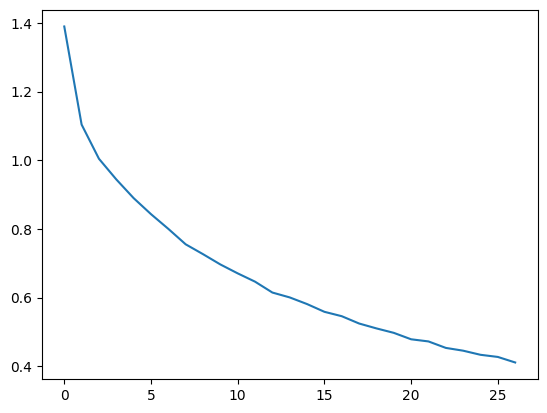

In [ ]:
# 결과 도식화
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure()
plt.plot(all_losses)
plt.show()

### 결과 평가

In [ ]:
def evaluate(rnn, testing_data, classes):
    confusion = torch.zeros(len(classes), len(classes))

    rnn.eval()
    with torch.no_grad():
        for i in range(len(testing_data)):
            (label_tensor, text_tensor, label, text) = testing_data[i]
            output = rnn(text_tensor)
            guess, guess_i = label_from_output(output, classes)
            label_i = classes.index(label)
            confusion[label_i][guess_i] += 1

    # Normalize by dividing every row by its sum
    for i in range(len(classes)):
        denom = confusion[i].sum()
        if denom > 0:
            confusion[i] = confusion[i] / denom

    fig = plt.figure()
    ax = fig.add_subplot(111)
    cax = ax.matshow(confusion.cpu().numpy())
    fig.colorbar(cax)

    ax.set_xticks(np.arange(len(classes)), labels=classes, rotation=90)
    ax.set_yticks(np.arange(len(classes)), labels=classes)

    ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

    plt.show()

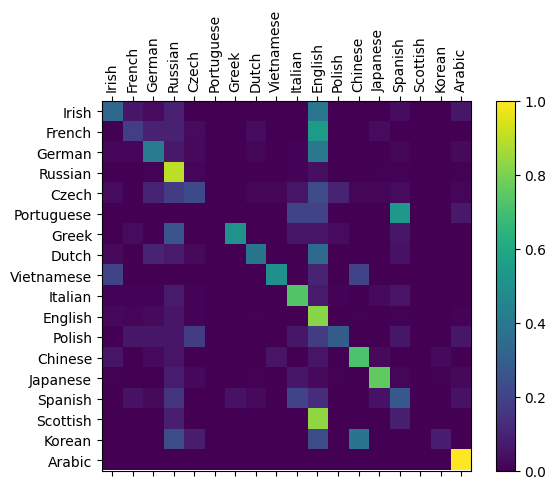

In [ ]:
evaluate(rnn, test_set, classes=alldata.labels_uniq)

## 2.finetuning_torchvision_models

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from __future__ import print_function
from __future__ import division
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
import copy
print("PyTorch Version: ",torch.__version__)
print("Torchvision Version: ",torchvision.__version__)

PyTorch Version:  2.11.0+cpu
Torchvision Version:  0.26.0+cpu


In [ ]:
data_dir = "/content/sample_data/hymenoptera_data"

In [ ]:
model_name = "squeezenet"

In [ ]:
num_classes = 2
batch_size = 8
num_epochs = 15
feature_extract = True

In [ ]:
def train_model(model, dataloaders, criterion, optimizer, num_epochs=25, is_inception=False):
    since = time.time()

    val_acc_history = []
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0

    for epoch in range(num_epochs):
        print("Epoch {}/{}".format(epoch, num_epochs - 1))
        print("-"*10)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            reuuning_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs = inputs.to(device)
                labels = labels.to(device)

                optimizer.zero_grad()
                with torch.set_grad_enabled(phase == 'train'):
                    if is_inception and phase == 'train':
                        outputs, aux_outputs = model(inputs)
                        loss1 = criterion(outputs, labels)
                        loss2 = criterion(aux_outputs, labels)
                        loss = loss1 + 0.4 * loss2
                    else:
                        outputs = model(inputs)
                        loss = criterion(outputs, labels)

                    _, preds = torch.max(outputs, 1)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(dataloaders[phase].dataset)
            epoch_acc = running_corrects.double() / len(dataloaders[phase].dataset)
            print('{} Loss: {:.4f} Acc: {:.4f}'.format(phase, epoch_loss, epoch_acc))

            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
            if phase == 'val':
                val_acc_history.append(epoch_acc)
        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best val Acc: {:4f}'.format(best_acc))

    model.load_state_dict(best_model_wts)
    return model, val_acc_history

In [ ]:
def set_parameter_requires_grad(model, feature_extracting):
    if feature_extracting:
        for param in model.parameters():
            param.requires_grad = False

In [ ]:
def initialize_model(model_name, num_classes, feature_extract, use_pretrained=True):
    model_ft = None
    input_size = 0

    if model_name =="rsenet":
        model_ft = models.resnet18(pretrained=use_pretrained)
        set_parameter_requires_grad(model_ft, feature_extract)
        num_ftrs = model_ft.fc.in_features
        model_ft.fc = nn.Linear(num_ftrs, num_classes)
        input_size = 224

    elif model_name == "alexnet":
        model_ft = models.alexnet(pretrained=use_pretrained)
        set_parameter_requires_grad(model_ft, feature_extract)
        num_ftrs = model_ft.classifier[6].in_features
        model_ft.classifier[6] = nn.Linear(num_ftrs, num_classes)
        input_size = 224

    elif model_name == "vgg":
        model_ft = models.vgg11_bn(pretrained=use_pretrained)
        set_parameter_requires_grad(model_ft, feature_extract)
        num_ftrs = model_ft.classifier[6].in_features
        model_ft.classifier[6] = nn.Linear(num_ftrs, num_classes)
        input_size = 224

    elif model_name == "squeezenet":
        model_ft = models.squeezenet1_0(pretrained=use_pretrained)
        set_parameter_requires_grad(model_ft, feature_extract)
        model_ft.classifier[1] = nn.Conv2d(512, num_classes, kernel_size=(1,1), stride=(1,1))
        model_ft.num_classes = num_classes
        input_size = 224

    elif model_name == "densenet":
        model_ft = models.densenet121(pretrained=use_pretrained)
        set_parameter_requires_grad(model_ft, feature_extract)
        num_ftrs = model_ft.classifier.in_features
        model_ft.classifier = nn.Linear(num_ftrs, num_classes)
        input_size = 224

    elif model_name == "inception":
        model_ft = models.inception_v3(pretrained=use_pretrained)
        set_parameter_requires_grad(model_ft, feature_extract)
        # 보조 네트워크(auxilary net) 처리
        num_ftrs = model_ft.AuxLogits.fc.in_features
        model_ft.AuxLogits.fc = nn.Linear(num_ftrs, num_classes)
        # 주 네트워크(primary net) 처리
        num_ftrs = model_ft.fc.in_features
        model_ft.fc = nn.Linear(num_ftrs,num_classes)
        input_size = 299

    else:
        print("Invalid model name, exiting...")
        exit()

    return model_ft, input_size

In [ ]:
# 실행을 위한 모델 초기화
model_ft, input_size = initialize_model(model_name, num_classes, feature_extract, use_pretrained=True)
print(model_ft)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SqueezeNet1_0_Weights.IMAGENET1K_V1`. You can also use `weights=SqueezeNet1_0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/squeezenet1_0-b66bff10.pth" to /root/.cache/torch/hub/checkpoints/squeezenet1_0-b66bff10.pth


100%|██████████| 4.78M/4.78M [00:00<00:00, 45.5MB/s]

SqueezeNet(
  (features): Sequential(
    (0): Conv2d(3, 96, kernel_size=(7, 7), stride=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=True)
    (3): Fire(
      (squeeze): Conv2d(96, 16, kernel_size=(1, 1), stride=(1, 1))
      (squeeze_activation): ReLU(inplace=True)
      (expand1x1): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
      (expand1x1_activation): ReLU(inplace=True)
      (expand3x3): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (expand3x3_activation): ReLU(inplace=True)
    )
    (4): Fire(
      (squeeze): Conv2d(128, 16, kernel_size=(1, 1), stride=(1, 1))
      (squeeze_activation): ReLU(inplace=True)
      (expand1x1): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 1))
      (expand1x1_activation): ReLU(inplace=True)
      (expand3x3): Conv2d(16, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (expand3x3_activation): ReLU(inplace=True)
    )
    (5): Fire(
   

In [ ]:
# 데이터 읽어 들이기
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(input_size),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(input_size),
        transforms.CenterCrop(input_size),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}
print("Initializing Datasets and Dataloaders...")

Initializing Datasets and Dataloaders...


In [ ]:
import shutil
import os

for split in ["train", "val"]:
    checkpoint_dir = os.path.join(data_dir, split, ".ipynb_checkpoints")
    if os.path.exists(checkpoint_dir):
        shutil.rmtree(checkpoint_dir)
        print("삭제:", checkpoint_dir)

In [ ]:
import os

for split in ["train", "val"]:
    print(split)
    print(os.listdir(os.path.join(data_dir, split)))

train
['bees', 'ants']
val
['bees', 'ants']


In [ ]:
# 학습 및 검증 데이터셋 생성
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['train', 'val']}
# 학습 및 검증 데이터로더(dataloader) 생성
dataloaders_dict = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=batch_size, shuffle=True, num_workers=4) for x in ['train', 'val']}

# 사용 가능한 GPU 탐지
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


In [ ]:
# GPU로 모델 전송
model_ft = model_ft.to(device)

In [ ]:
params_to_update = model_ft.parameters()
print("Params to learn:")

if feature_extract:
    params_to_update = []
    for name, param in model_ft.named_parameters():
        if param.requires_grad == True:
            params_to_update.append(param)
            print("\t", name)
else:
    for name, param in model_ft.named_parameters():
        if param.requires_grad == True:
            print("\t", name)

optimizer_ft = optim.SGD(params_to_update, lr=0.001, momentum=0.9)

NameError: name 'model_ft' is not defined

### 학습 및 검증 단계 실행

In [ ]:
# 손실 함수 설정
criterion = nn.CrossEntropyLoss()

# 학습 및 평가
model_ft, hist = train_model(model_ft, dataloaders_dict, criterion, optimizer_ft,
                             num_epochs=num_epochs, is_inception=(model_name=="inception"))

In [ ]:
# 이 실행에 사용된 모델의 사전 학습되지 않은 버전을 초기화합니다.
scratch_model,_ = initialize_model(model_name, num_classes, feature_extract=False, use_pretrained=False)
scratch_model = scratch_model.to(device)
scratch_optimizer = optim.SGD(scratch_model.parameters(), lr=0.001, momentum=0.9)
scratch_criterion = nn.CrossEntropyLoss()
_,scratch_hist = train_model(scratch_model, dataloaders_dict, scratch_criterion, scratch_optimizer, num_epochs=num_epochs, is_inception=(model_name=="inception"))

In [ ]:
ohist = []
shist = []

ohist = [h.cpu().numpy() for h in hist]
shist = [h.cpu().numpy() for h in scratch_hist]

plt.title("Validation Accuracy vs. Number of Training Epochs")
plt.xlabel("Training Epochs")
plt.ylabel("Validation Accuracy")
plt.plot(range(1, num_epochs+1), ohist, label="Pretrained")
plt.plot(range(1, num_epochs + 1), shist, label="Scratch")
plt.ylim((0, 1.))
plt.xticks(np.arange(1, num_epochs + 1, 1.0))
plt.legend()
plt.show()

## 3.Ray Tune을 사용한 하이퍼파라미터 튜닝

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install -q ray

In [ ]:
from functools import partial
import os
import tempfile
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import random_split
import torchvision
import torchvision.transforms as transforms

import sys
if not hasattr(sys.stdout, "encoding"):
    sys.stdout.encoding = "latin1"
    sys.stdout.fileno = lambda: 0

from ray import tune
from ray import train
from ray.train import Checkpoint, get_checkpoint
from ray.tune.schedulers import ASHAScheduler
import ray.cloudpickle as pickle

In [ ]:
def load_data(data_dir="./data"):
    transform = transforms.Compose([
        [transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))]
    ])
    trainset = torchvision.datasets.CIFAR10(
        root=data_dir, train=True, download=True, transform=transform
    )
    testset = torchvision.datasets.CIFAR10(
        root=data_dir, train=False, download=True, transform=transform
    )
    return trainset, testset

In [ ]:
class Net(nn.Module):
    def __init__(self, l1=120, l2=84):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, l1)
        self.fc2 = nn.Linear(l1, l2)
        self.fc3 = nn.Linear(l2, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

In [ ]:
def train_cifar(config, data_dir=None):
    net = Net(config["l1"], config["l2"])

    device = "cpu"
    if torch.cuda.is_available():
        device = "cuda"
        if torch.cuda.device_count() > 1:
            net = nn.DataParallel(net)
    net.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(net.parameters(), lr=config["lr"], momentum=0.9)

    checkpoint = get_checkpoint()
    if checkpoint:
        with checkpoint.as_directory() as checkpoint_dir:
            data_path = Path(checkpoint_dir) / "data.pkl"
            with open(data_path, "rb") as fp:
                checkpoint_state = pickle.load(fp)
            start_epoch = checkpoint_state['epoch']
            net.load_state_dict(checkpoint_state['net_state_dict'])
            optimizer.load_state_dict(checkpoint_state['optimizer_state_dict'])
    else:
        start_epoch = 0

    trainset, testset = load_data(data_dir)

    test_abs = int(len(trainset) * 0.8)
    train_subset, val_subset = random_split(
        trainset, [test_abs, len(trainset) - test_abs]
    )

    trainloader = torch.utils.data.DataLoader(
        train_subset, batch_size=(config["batch_size"]), shuffle=True, num_workers=8
    )
    valloader = torch.utils.data.DataLoader(
        val_subset, batch_size=(config["batch_size"]), shuffle=True, num_workers=8
    )

    for epoch in range(start_epoch, 10):
        running_loss = 0.0
        epoch_steps = 0
        for i, data in enumerate(trainloader, 0):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)

            # zero the parameter gradients
            optimizer.zero_grad()

            # forward + backward + optimize
            outputs = net(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # print statistics
            running_loss += loss.item()
            epoch_steps += 1
            if i % 2000 == 1999:
                print(
                    "[%d, %5d] loss: %.3f"
                    % (epoch + 1, i + 1, running_loss / epoch_steps)
                )
                running_loss = 0.0

        # Validation loss
        val_loss = 0.0
        val_steps = 0
        total = 0
        correct = 0
        for i, data in enumerate(valloader, 0):
            with torch.no_grad():
                inputs, labels = data
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = net(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

                loss = criterion(outputs, labels)
                val_loss += loss.cpu().numpy()
                val_steps += 1

        checkpoint_data = {
            "epoch": epoch,
            "net_state_dict": net.state_dict(),
            "optimizer_state_dict": optimizer.state_dict()
        }
        with tempfile.TemporaryDirectory() as checkpoint_dir:
            data_path = Path(checkpoint_dir) / "data.pkl"
            with open(data_path, "wb") as fp:
                pickle.dump(checkpoint_data, fp)

            checkpoint = Checkpoint.from_directory(checkpoint_dir)
            train.report(
                {"loss": val_loss / val_steps, "accuracy": correct / total},
                checkpoint = checkpoint
            )

    print("Finishing Training")

In [ ]:
def test_accuracy(net, device="cpu"):
    trainset, testset = load_data()

    testloader = torch.utils.data.DataLoader(
        testset, batch_size=4, shuffle=False, num_workers=2
    )

    correct = 0
    total = 0
    with torch.no_grad():
        for data in testloader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = net(images)
            _, predicted = torch.max(outputs,data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return correct / total

In [ ]:
def main(num_samples=10, max_num_epochs=10, gpus_per_trial=2):
    data_dir = os.path.abspath("./data")
    load_data(data_dir)
    config = {
        "l1": tune.choice([2**i for i in range(9)]),
        "l2": tune.choice([2**i for i in range(9)]),
        "lr": tune.loguniform(1e-4, 1e-1),
        "batch_size": tune.choice([2, 4, 8, 16])
    }
    scheduler = ASHAScheduler(
        metric="loss",
        mode="min",
        max_t=max_num_epochs,
        grace_period=1,
        reduction_factor=2
    )
    result = tune.run(
        partial(train_cifar, data_dir=data_dir),
        resources_per_trial={"cpu": 2, "gpu": gpus_per_trial},
        config=config,
        num_samples=num_samples,
        scheduler=scheduler
    )

    best_trial = result.get_best_trial("loss", "min", "last")
    print(f"Best trial config: {best_trial.config}")
    print(f"Best trial final validation loss: {best_trial.last_result['loss']}")
    print(f"Best trial final validation accuracy: {best_trial.last_result['accuracy']}")

    best_trained_model = Net(best_trial.config["l1"], best_trial.config["l2"])
    device = "cpu"
    if torch.cuda.is_available():
        device = "cuda"
        if gpus_per_trial > 1:
            best_trial_model = nn.DataParallel(best_trial_model)
    best_trial_model.to(device)

    best_checkpoint = result.get_best_checkpoint(trial=best_trial, metric="accuracy", mode="max")
    with best_checkpoint.as_directory() as checkpoint_dir:
        data_path = Path(checkpoint_dir) / "data.pkl"
        with open(data_path, "rb") as fp:
            best_checkpoint_data = pickle.load(fp)

        best_trained_model.load_state_dict(best_checkpoint_data["net_state_dict"])
        test_acc = test_accuracy(best_trained_model, device)
        print("Best trial test set accuracy: {}".format(test_acc))

In [ ]:
if __name__ == "__main__":
    main(num_samples=10, max_num_epochs=10, gpus_per_trial=0)

100%|██████████| 170M/170M [15:09<00:00, 187kB/s]
2026-07-02 19:46:42,227	INFO worker.py:2024 -- Started a local Ray instance.
2026-07-02 19:46:46,971	INFO tune.py:253 -- Initializing Ray automatically. For cluster usage or custom Ray initialization, call `ray.init(...)` before `tune.run(...)`.
2026-07-02 19:46:47,043	INFO tensorboardx.py:43 -- pip install "ray[tune]" to see TensorBoard files.
2026-07-02 19:46:47,044	WARNING callback.py:132 -- The TensorboardX logger cannot be instantiated because either TensorboardX or one of it's dependencies is not installed. Please make sure you have the latest version of TensorboardX installed: `pip install -U tensorboardx`


+--------------------------------------------------------------------+
| Configuration for experiment     train_cifar_2026-07-02_19-46-47   |
+--------------------------------------------------------------------+
| Search algorithm                 BasicVariantGenerator             |
| Scheduler                        AsyncHyperBandScheduler           |
| Number of trials                 10                                |
+--------------------------------------------------------------------+

View detailed results here: /root/ray_results/train_cifar_2026-07-02_19-46-47

Trial status: 10 PENDING
Current time: 2026-07-02 19:46:47. Total running time: 0s
Logical resource usage: 2.0/2 CPUs, 0/0 GPUs
+-------------------------------------------------------------------------------+
| Trial name                status       l1     l2            lr     batch_size |
+-------------------------------------------------------------------------------+
| train_cifar_c2a67_00000   PENDING      64     1

2026-07-02 19:47:00,498	ERROR tune_controller.py:1332 -- Trial task failed for trial train_cifar_c2a67_00000
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/ray/air/execution/_internal/event_manager.py", line 110, in resolve_future
    result = ray.get(future)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ray/_private/auto_init_hook.py", line 22, in auto_init_wrapper
    return fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ray/_private/client_mode_hook.py", line 110, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ray/_private/worker.py", line 2968, in get
    values, debugger_breakpoint = worker.get_objects(
                                  ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ray/_private/worker.py", line 1050, in get_objects
    raise value.as_instanceof_caus


Trial train_cifar_c2a67_00000 errored after 0 iterations at 2026-07-02 19:47:00. Total running time: 13s
Error file: /tmp/ray/session_2026-07-02_19-46-27_034066_21941/artifacts/2026-07-02_19-46-47/train_cifar_2026-07-02_19-46-47/driver_artifacts/train_cifar_c2a67_00000_0_batch_size=16,l1=64,l2=16,lr=0.0008_2026-07-02_19-46-47/error.txt

Trial train_cifar_c2a67_00001 started with configuration:
+--------------------------------------------------+
| Trial train_cifar_c2a67_00001 config             |
+--------------------------------------------------+
| batch_size                                     8 |
| l1                                           128 |
| l2                                            64 |
| lr                                       0.00143 |
+--------------------------------------------------+


2026-07-02 19:47:13,184	ERROR tune_controller.py:1332 -- Trial task failed for trial train_cifar_c2a67_00001
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/ray/air/execution/_internal/event_manager.py", line 110, in resolve_future
    result = ray.get(future)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ray/_private/auto_init_hook.py", line 22, in auto_init_wrapper
    return fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ray/_private/client_mode_hook.py", line 110, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ray/_private/worker.py", line 2968, in get
    values, debugger_breakpoint = worker.get_objects(
                                  ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ray/_private/worker.py", line 1050, in get_objects
    raise value.as_instanceof_caus

...

2026-07-02 19:48:40,610	ERROR tune_controller.py:1332 -- Trial task failed for trial train_cifar_c2a67_00008
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/ray/air/execution/_internal/event_manager.py", line 110, in resolve_future
    result = ray.get(future)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ray/_private/auto_init_hook.py", line 22, in auto_init_wrapper
    return fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ray/_private/client_mode_hook.py", line 110, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ray/_private/worker.py", line 2968, in get
    values, debugger_breakpoint = worker.get_objects(
                                  ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ray/_private/worker.py", line 1050, in get_objects
    raise value.as_instanceof_caus


Trial train_cifar_c2a67_00008 errored after 0 iterations at 2026-07-02 19:48:40. Total running time: 1min 53s
Error file: /tmp/ray/session_2026-07-02_19-46-27_034066_21941/artifacts/2026-07-02_19-46-47/train_cifar_2026-07-02_19-46-47/driver_artifacts/train_cifar_c2a67_00008_8_batch_size=4,l1=64,l2=4,lr=0.0029_2026-07-02_19-46-47/error.txt

Trial status: 9 ERROR | 1 PENDING
Current time: 2026-07-02 19:48:47. Total running time: 2min 0s
Logical resource usage: 2.0/2 CPUs, 0/0 GPUs
+-------------------------------------------------------------------------------+
| Trial name                status       l1     l2            lr     batch_size |
+-------------------------------------------------------------------------------+
| train_cifar_c2a67_00009   PENDING       1      8   0.00652206               4 |
| train_cifar_c2a67_00000   ERROR        64     16   0.000830586             16 |
| train_cifar_c2a67_00001   ERROR       128     64   0.00143031               8 |
| train_cifar_c2a67_000

2026-07-02 19:48:54,494	ERROR tune_controller.py:1332 -- Trial task failed for trial train_cifar_c2a67_00009
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/ray/air/execution/_internal/event_manager.py", line 110, in resolve_future
    result = ray.get(future)
             ^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ray/_private/auto_init_hook.py", line 22, in auto_init_wrapper
    return fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ray/_private/client_mode_hook.py", line 110, in wrapper
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ray/_private/worker.py", line 2968, in get
    values, debugger_breakpoint = worker.get_objects(
                                  ^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/ray/_private/worker.py", line 1050, in get_objects
    raise value.as_instanceof_caus


Trial train_cifar_c2a67_00009 errored after 0 iterations at 2026-07-02 19:48:54. Total running time: 2min 7s
Error file: /tmp/ray/session_2026-07-02_19-46-27_034066_21941/artifacts/2026-07-02_19-46-47/train_cifar_2026-07-02_19-46-47/driver_artifacts/train_cifar_c2a67_00009_9_batch_size=4,l1=1,l2=8,lr=0.0065_2026-07-02_19-46-47/error.txt

Trial status: 10 ERROR
Current time: 2026-07-02 19:48:54. Total running time: 2min 7s
Logical resource usage: 2.0/2 CPUs, 0/0 GPUs
+-------------------------------------------------------------------------------+
| Trial name                status       l1     l2            lr     batch_size |
+-------------------------------------------------------------------------------+
| train_cifar_c2a67_00000   ERROR        64     16   0.000830586             16 |
| train_cifar_c2a67_00001   ERROR       128     64   0.00143031               8 |
| train_cifar_c2a67_00002   ERROR        64      4   0.00090954               2 |
| train_cifar_c2a67_00003   ERROR   

TuneError: ('Trials did not complete', [train_cifar_c2a67_00000, train_cifar_c2a67_00001, train_cifar_c2a67_00002, train_cifar_c2a67_00003, train_cifar_c2a67_00004, train_cifar_c2a67_00005, train_cifar_c2a67_00006, train_cifar_c2a67_00007, train_cifar_c2a67_00008, train_cifar_c2a67_00009])

## 4.컴퓨터 비전(Vision)을 위한 전이학습(Transfer Learning)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
import torch.backends.cudnn as cudnn
import numpy as np
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt
import time
import os
from PIL import Image
from tempfile import TemporaryDirectory

cudnn.benchmark = True
plt.ion()

In [ ]:
data_transforms = {
    'train':transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])
}

In [ ]:
data_dir = ''
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x),
                    data_transforms[x]) for x in ['train', 'val']}
dataloaders = {x: torch.utils.data.DataLoader(image_datasets[x], batch_size=4,
                    shuffle=True, num_workers=4) for x in ['train', 'val']}
dataset_sizes = {x: len(image_datasets[x]) for x in ['train', 'val']}
class_names = image_datasets['train'].classes

FileNotFoundError: [Errno 2] No such file or directory: 'train'

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device} device")

Using cuda device


In [ ]:
# 일부 이미지 시각화하기
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)

In [ ]:
# 학습 데이터의 배치를 얻습니다.
inputs, classes = next(iter(dataloaders['train']))
out = torchvision.utils.make_grid(inputs)
imshow(out, title=[class_names[x] for x in classes])

NameError: name 'dataloaders' is not defined

### 4-1.모델 학습하기

In [ ]:
def train_model(model, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()

    # Create a temporary directory to save training checkpoints
    with TemporaryDirectory() as tempdir:
        best_model_params_path = os.path.join(tempdir, 'best_model_params.pt')

        torch.save(model.state_dir(), best_model_params_path)
        best_acc = 0.0

        for epoch in range(num_epochs):
            print(f'Epoch {epoch} / {num_epochs - 1}')
            print('-' * 10)

            for phase in ['train', 'val']:
                if phase == 'train':
                    model.train()
                else:
                    model.eval()

                running_loss = 0.0
                running_corrects = 0

                # 데이터를 반복
                for inputs, labels in dataloaders[phase]:
                    inputs = inputs.to(device)
                    labels = labels.to(device)

                    # 매개변수 경사도를 0으로 설정
                    optimizer.zero_grad()

                    with torch.set_grad_enabled(phase == 'train'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                        if phase == 'train':
                            loss.backward()
                            optimizer.step()

                    running_loss += loss.item() * inputs.size(0)
                    running_corrects += torch.sum(preds == labels.data)
                if phase == 'train':
                    scheduler.step()

                epoch_loss = running_loss / dataset_sizes[phase]
                epoch_acc = running_corrects.double() / dataset_sizes[phase]

                print(f'{phase} Loss: {epoch_loss:.4f} Acc" {epoch_acc:.4f}')

                if phase == 'val' and epoch_acc > best_acc:
                    best_acc = epoch_acc
                    torch.save(model.state_dict(), best_model_params_path)

            print()

        time_elapsed = time.time() - since
        print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
        print(f'Best val Acc: {best_acc:4f}')

        # 가장 나은 모델 가중치를 불러오기
        model.load_state_dict(torch.load(best_model_params_path, weights_only=True))
    return model

### 4-2.모델 예측값 시각화

In [ ]:
def visualize_model(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    fig = plt.figure()

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['val']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images // 2, 2, images_so_far)
                ax.axis('off')
                ax.set_title(f'predicted: {class_names[preds[j]]}')
                imshow(inputs.cpu().data[j])

                if images_so_far == num_images:
                    model.train(mode = was_training)
                    return
        model.train(mode=was_training)

In [ ]:
# 합성곱 신경망 미세조정(finetuning)
model_ft = models.resnet18(weights='IMAGENET1K_V1')
num_ftrs = model_ft.fc.in_features
model_ft.fc = nn.Linear(num_ftrs, 2)

model_ft = model_ft.to(device)

criterion = nn.CrossEntropyLoss()

optimizer_ft = optim.SGD(model_ft.parameters(), lr=0.001, momentum=0.9)

exp_lr_scheduler = lr_scheduler.StepLR(optimizer_ft, step_size=7, gamma=0.1)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 189MB/s]


In [ ]:
#  학습 및 평가하기( CPU에서는 15-25분가량, GPU에서는 1분 이내)
model_ft = train_model(model_ft, criterion, optimizer_ft, exp_lr_scheduler,num_epochs=25)

AttributeError: 'ResNet' object has no attribute 'state_dir'

In [ ]:
visualize_model(model_ft)

NameError: name 'dataloaders' is not defined

<Figure size 640x480 with 0 Axes>

In [ ]:
model_conv = torchvision.models.resnet18(weights='IMAGENET1K_V1')
for param in model_conv.parameters():
    param.requires_grad = False

In [ ]:
# 새로 생성된 모듈의 매개변수는 기본값이 requires_grad=True 임
num_ftrs = model_conv.fc.in_features
model_conv.fc = nn.Linear(num_ftrs, 2)

model_conv = model_conv.to(device)

criterion = nn.CrossEntropyLoss()

optimizer_conv = optim.SGD(model_conv.fc.parameters(), lr=0.001, momentum=0.9)
exp_lr_scheduler = lr_scheduler.StepLR(optimizer_conv, step_size=7, gamma=0.1)

In [ ]:
# 학습 및 평가하기
model_conv = train_model(model_conv, criterion, optimizer_conv,
                         exp_lr_scheduler, num_epochs=25)
visualize_model(model_conv)

plt.ioff()
plt.show()

AttributeError: 'ResNet' object has no attribute 'state_dir'

In [ ]:
# 다른 이미지들에 대한 추론
def visualize_model_predictions(model, img_path):
    was_training = model.training
    model.eval()

    img = Image.open(img_path)
    img = data_transforms['val'](img)
    img = img.unsqueeze(0)
    img = img.to(device)

    with torch.no_grad():
        outputs = model(img)
        _, preds = torch.max(outputs, 1)

        ax = plt.subplot(2,2,1)
        ax.axis('off')
        ax.set_title(f'Predicted: {class_names[0]}')
        imshow(img.cpu().data[0])

        model.train(mode=was_training)

NameError: name 'class_names' is not defined

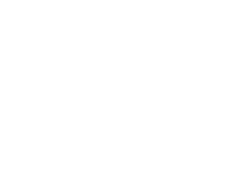

In [ ]:
visualize_model_predictions(
    model_conv,
    img_path='/content/6743948_2b8c096dda.jpg'
)
plt.ioff()
plt.show()

## 5.Transform을 이용한 시퀀스-투-시퀀스(Sequence-to-Sequence) 모델링

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip -q install datasets

In [ ]:
import math
from collections import Counter

import torch
from torch import nn, Tensor

from datasets import load_dataset

from torchtext.data.utils import get_tokenizer
from torchtext.vocab import vocab

OSError: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchtext/lib/libtorchtext.so

In [ ]:
import math
import os
from tempfile import TemporaryDirectory
from typing import Tuple

import torch
from torch import nn, Tensor
import torch.nn.functional as F
from torch.nn import TransformerEncoder, TransformerEncoderLayer
from torch.utils.data import dataset

In [ ]:
class TransformerModel(nn.Module):
    def __init__(self, ntoken: int, d_model: int, nhead: int, d_hid: int,
                 nlayers: int, dropout: float=0.5):
        super().__init__()
        self.model_type = 'Transformer'
        self.pos_encoder = PositionalEncoding(d_model, dropout)
        encoder_layers = TransformerEncoderLayer(d_model, nhead, d_hid, dropout)
        self.transformer_encoder = TransformerEncoder(encoder_layers, nlayers)
        self.encoder = nn.Embedding(ntoken, d_model)
        self.d_model = d_model
        self.decoder = nn.Linear(d_model, ntoken)

        self.init_weights()

    def init_weights(self) -> None:
        initrange = 0.1
        self.encoder.weight.data.uniform_(-initrange, initrange)
        self.decoder.bias.data.zero_()
        self.decoder.weight.data.uniform_(-initrange, initrange)

    def forward(self, src: Tensor, src_mask: Tensor) -> Tensor:
        src = self.encoder(src) * math.sqrt(self.d_model)
        src = self.pos_encoder(src)
        output = self.transformer_encoder(src, src_mask)
        return output

In [ ]:
def generate_square_subsequent_mask(sz: int) -> Tensor:
    return torch.triu(torch.ones(sz, sz) * float('-inf'), diagonal=1)

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, dropout: float=0.1, max_len: int=5000):
        super().__init__()
        self.dropout = nn.Dropout(p=dropout)

        position = torch.arange(max_len).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
        pe = torch.zeros(max_len, 1, d_model)
        pe[:, 0, 0::2] = torch.sin(position * div_term)
        pe[:, 0, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe)

    def forward(self, x: Tensor) -> Tensor:
        x = x + self.pe[:x.size(0)]
        return self.dropout(x)

In [ ]:
!pip -q install datasets

In [ ]:
import torch
print(torch.__version__)

2.11.0+cu128


In [ ]:
import torch
from torch import Tensor
from collections import Counter
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import vocab
from datasets import load_dataset

OSError: Could not load this library: /usr/local/lib/python3.12/dist-packages/torchtext/lib/libtorchtext.so

## 6.chatbot_tutorial

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import torch
from torch.jit import script, trace
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
import csv
import random
import re
import os
import unicodedata
import codecs
from io import open
import itertools
import math
import json

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"using {device} device")

using cuda device


In [24]:
corpus_name = "cornell movie-dialogs corpus"
corpus = os.path.join("/content/data", corpus_name)

In [25]:
def printLines(file, n=10):
    with open(file, 'rb') as datafile:
        lines = datafile.readlines()
    for line in lines[:n]:
        print(line)

In [26]:
printLines(os.path.join(corpus, "/content/data/utterances.jsonl"))

b'{"id": "L1045", "conversation_id": "L1044", "text": "They do not!", "speaker": "u0", "meta": {"movie_id": "m0", "parsed": [{"rt": 1, "toks": [{"tok": "They", "tag": "PRP", "dep": "nsubj", "up": 1, "dn": []}, {"tok": "do", "tag": "VBP", "dep": "ROOT", "dn": [0, 2, 3]}, {"tok": "not", "tag": "RB", "dep": "neg", "up": 1, "dn": []}, {"tok": "!", "tag": ".", "dep": "punct", "up": 1, "dn": []}]}]}, "reply-to": "L1044", "timestamp": null, "vectors": []}\n'
b'{"id": "L1044", "conversation_id": "L1044", "text": "They do to!", "speaker": "u2", "meta": {"movie_id": "m0", "parsed": [{"rt": 1, "toks": [{"tok": "They", "tag": "PRP", "dep": "nsubj", "up": 1, "dn": []}, {"tok": "do", "tag": "VBP", "dep": "ROOT", "dn": [0, 2, 3]}, {"tok": "to", "tag": "TO", "dep": "dobj", "up": 1, "dn": []}, {"tok": "!", "tag": ".", "dep": "punct", "up": 1, "dn": []}]}]}, "reply-to": null, "timestamp": null, "vectors": []}\n'
b'{"id": "L985", "conversation_id": "L984", "text": "I hope so.", "speaker": "u0", "meta": {

In [27]:
def loadLinesAndConversations(filename):
    lines = {}
    conversations = {}
    with open(filename, 'r', encoding='iso-8859-1') as f:
        for line in f:
            lineJson = json.loads(line)
            # 필드를 추출하여 line 객체를 구성
            lineObj = {}
            lineObj["lineID"] = lineJson["id"]
            lineObj["characterID"] = lineJson["speaker"]
            lineObj["text"] = lineJson["text"]
            lines[lineObj['lineID']] = lineObj

            # 필드를 추출하여 conversation 객체를 구성
            if lineJson["conversation_id"] not in conversations:
                convObj = {}
                convObj["conversationID"] = lineJson["conversation_id"]
                convObj["movieID"] = lineJson["meta"]["movie_id"]
                convObj["lines"] = [lineObj]
            else:
                convObj = conversations[lineJson["conversation_id"]]
                convObj["lines"].insert(0, lineObj)
            conversations[convObj["conversationID"]] = convObj

    return lines, conversations

In [28]:
# conversation들에서 문장 쌍을 추출
def extractSentencePairs(conversations):
    qa_pairs = []
    for conversation in conversations.values():
        # 대화를 이루는 각 대사에 대해 반복문을 수행
        # 대화의 마지막 대사는 (그에 대한 응답이 없으므로) 무시
        for i in range(len(conversation["lines"]) - 1):
            inputLine = conversation["lines"][i]["text"].strip()
            targetLine = conversation["lines"][i+1]["text"].strip()
            # 잘못된 샘플은 제거(리스트가 하나라도 비어 있는 경우)
            if inputLine and targetLine:
                qa_pairs.append([inputLine, targetLine])
    return qa_pairs

In [29]:
# 새 파일에 대한 경로를 정의
datafile = os.path.join(corpus, "formatted_movie_lines.txt")

delimiter = "\t"
# 구분자에 대해 unescape 함수를 호출
delimiter = str(codecs.decode(delimiter, "unicode_escape"))

In [30]:
# 대사 사전(lines dict)과 대화 사전(conversations dict)을 초기화
lines = {}
conversations = {}
# 대사와 대화를 불러옴
print("\nProcessing corpus into lines and conversations...")
lines, conversations = loadLinesAndConversations(os.path.join(corpus, "/content/data/utterances.jsonl"))


Processing corpus into lines and conversations...


In [31]:
import os

os.makedirs(os.path.dirname(datafile), exist_ok=True)

print("Writing newly formatted file...")

with open(datafile, "w", encoding="utf-8", newline="") as outputfile:
    writer = csv.writer(outputfile,
                        delimiter=delimiter,
                        lineterminator="\n")

    for pair in extractSentencePairs(conversations):
        writer.writerow(pair)

Writing newly formatted file...


In [32]:
# # 결과를 새로운 csv 파일로 저장
# print("\nWriting newly formatted file...")
# with open(datafile, 'w', encoding='utf-8') as outputfile:
#     writer = csv.writer(outputfile, delimiter=delimiter, lineterminator='\n')
#     for pair in extractSentencePairs(conversations):
#         writer.writerow(pair)

In [33]:
print("\nSample lines from file:")
printLines(datafile)


Sample lines from file:
b'They do to!\tThey do not!\n'
b'She okay?\tI hope so.\n'
b"Wow\tLet's go.\n"
b'"I\'m kidding.  You know how sometimes you just become this ""persona""?  And you don\'t know how to quit?"\tNo\n'
b"No\tOkay -- you're gonna need to learn how to lie.\n"
b"I figured you'd get to the good stuff eventually.\tWhat good stuff?\n"
b'What good stuff?\t"The ""real you""."\n'
b'"The ""real you""."\tLike my fear of wearing pastels?\n'
b'do you listen to this crap?\tWhat crap?\n'
b"What crap?\tMe.  This endless ...blonde babble. I'm like, boring myself.\n"


### 6-2.데이터 읽고 정리하기

In [34]:
# 기본 단어 토큰 값
PAD_token = 0  # 짧은 문장을 채울(패딩, PADding) 때 사용할 제로 토큰
SOS_token = 1  # 문장의 시작(SOS, Start Of Sentence)을 나타내는 토큰
EOS_token = 2  # 문장의 끝(EOS, End Of Sentence)을 나태는 토큰

In [35]:
class Voc:
    def __init__(self, name):
        self.name = name
        self.trimmed = False
        self.word2index = {}
        self.word2count = {}
        self.index2word = {PAD_token: "PAD", SOS_token: "SOS", EOS_token: "EOS"}
        self.num_words = 3  # SOS, EOS, PAD를 센 것

    def addSentence(self, sentence):
        for word in sentence.split(' '):
            self.addWord(word)

    def addWord(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.num_words
            self.word2count[word] = 1
            self.index2word[self.num_words] = word
            self.num_words += 1
        else:
            self.word2count[word] += 1

    # 등장 횟수가 기준 이하인 단어를 정리
    def trim(self, min_count):
        if self.trimmed:
            return
        self.trimmed = True

        keep_words = []

        for k, v in self.word2count.items():
            if v >= min_count:
                keep_words.append(k)

        print('kee_words {} / {} = {:.4f}'.format(
            len(keep_words), len(self.word2index), len(keep_words) / len(self.word2index)
        ))

        # 사전을 다시 초기화
        self.word2index = {}
        self.word2count = {}
        self.index2word = {PAD_token: "PAD", SOS_token: "SOS", EOS_token: "EOS"}
        self.num_words = 3  # 기본 토큰을 센 것

        for word in keep_words:
            self.addWord(word)

In [36]:
MAX_LENGTH = 10  # 고려할 문장의 최대 길이

# 유니코드 문자열을 아스키로 변환
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn'
    )

In [37]:
# 소문자로 만들고, 공백을 넣고, 알파벳 외의 글자를 제거
def normalizeString(s):
    s = unicodeToAscii(s.lower().strip())
    s = re.sub(r"([.!?])", r" \1", s)
    s = re.sub(r"[^a-zA-Z.!?]+", r" ", s)
    s = re.sub(r"\s+", r" ", s).strip()
    return s

In [38]:
# 질의/응답 쌍을 읽어서 voc 객체를 반환
def readVocs(datafile, corpus_name):
    print("reading lines...")
    # 파일을 읽고, 쪼개어 lines에 저장
    lines = open(datafile, encoding='utf-8').read().strip().split('\n')
    # 각 줄을 쪼개어 pairs에 저장하고 정규화
    pairs = [[normalizeString(s) for s in l.split('\t')] for l in lines]
    voc = Voc(corpus_name)
    return voc, pairs

In [39]:
# 문장의 쌍 'p'에 포함된 두 문장이 모두 MAX_LENGTH라는 기준보다 짧은지를 반환
def filterPair(p):
    # EOS 토큰을 위해 입력 시퀀스의 마지막 단어를 보존
    return len(p[0].split(' ')) < MAX_LENGTH and len(p[1].split(' ')) < MAX_LENGTH

In [40]:
# 조건식 ``filterPair`` 에 따라 pairs를 필터링
def filterPairs(pairs):
    return [pair for pair in pairs if filterPair(pair)]

In [41]:
# 앞에서 정의한 함수를 이용하여 만든 voc 객체와 리스트 pairs를 반환
def loadPrepareData(corpus, corpus_name, datafile, save_dir):
    print("Start preparing training data ...")
    voc, pairs = readVocs(datafile, corpus_name)
    print("Read {!s} sentence pairs".format(len(pairs)))
    pairs = filterPairs(pairs)
    print("Trimmed to {!s} sentence pairs".format(len(pairs)))
    print("Counting words...")
    for pair in pairs:
        voc.addSentence(pair[0])
        voc.addSentence(pair[1])
    print("Counted words:", voc.num_words)
    return voc, pairs

In [42]:
# voc와 pairs를 읽고 재구성
save_dir = os.path.join("data", "save")
voc, pairs = loadPrepareData(corpus, corpus_name, datafile, save_dir)
# 검증을 위해 pairs의 일부 내용을 출력해 봅니다
print("\npairs:")
for pair in pairs[:10]:
    print(pair)

Start preparing training data ...
reading lines...
Read 221282 sentence pairs
Trimmed to 64313 sentence pairs
Counting words...
Counted words: 18082

pairs:
['they do to !', 'they do not !']
['she okay ?', 'i hope so .']
['wow', 'let s go .']
['what good stuff ?', 'the real you .']
['the real you .', 'like my fear of wearing pastels ?']
['do you listen to this crap ?', 'what crap ?']
['well no . . .', 'then that s all you had to say .']
['then that s all you had to say .', 'but']
['but', 'you always been this selfish ?']
['have fun tonight ?', 'tons']


In [43]:
# 학습 단계가 빨리 수렴하도록 하는 또 다른 전략은 자주 쓰이지 않는 단어를
# 어휘집에서 제거 즉
#1) ``voc.trim`` 함수를 이용하여 ``MIN_COUNT`` 라는 기준 이하의 단어를 제거#
# 2) 제거하기로 한 단어를 포함하는 경우를 pairs에서 제외

In [44]:
MIN_COUNT = 3    # 제외할 단어의 기준이 되는 등장 횟수

def trimRareWords(voc, pairs, MIN_COUNT):
    # MIN_COUNT 미만으로 사용된 단어는 voc에서 제외
    voc.trim(MIN_COUNT)
    # 제외할 단어가 포함된 경우를 pairs에서도 제외
    keep_pairs = []
    for pair in pairs:
        input_sentence = pair[0]
        output_sentence = pair[1]
        keep_input = True
        keep_output = True
        # 입력 문장을 검사
        for word in input_sentence.split(' '):
            if word not in voc.word2index:
                keep_input = False
                break
        # 출력 문장을 검사
        for word in output_sentence.split(' '):
            if word not in voc.word2index:
                keep_output = False
                break

        # 입출력 문장에 제외하기로 한 단어를 포함하지 않는 경우만을 남겨둠
        if keep_input and keep_output:
            keep_pairs.append(pair)

    print("Trimmed from {} pairs to {}, {:.4f} of total".format(len(pairs), len(keep_pairs), len(keep_pairs) / len(pairs)))
    return keep_pairs

In [45]:
# voc와 pairs를 정돈
pairs = trimRareWords(voc, pairs, MIN_COUNT)

kee_words 7833 / 18079 = 0.4333
Trimmed from 64313 pairs to 53131, 0.8261 of total


### 6-3.모델을 위한 데이터 준비하기

In [46]:
def indexesFromSentence(voc, sentence):
    return [voc.word2index[word] for word in sentence.split(' ')] + [EOS_token]

In [48]:
def zeroPadding(l, fillvalue=PAD_token):
    return list(itertools.zip_longest(*l, fillvalue=fillvalue))

In [49]:
def binaryMatrix(l, value=PAD_token):
    m = []
    for i, seq in enumerate(l):
        m.append([])
        for token in seq:
            if token == PAD_token:
                m[i].append(0)
            else:
                m[i].append(1)
    return m

In [50]:
# 입력 시퀀스 텐서에 패딩한 결과와 lengths를 반환
def inputVar(l, voc):
    indexes_batch = [indexesFromSentence(voc, sentence) for sentence in l]
    lengths = torch.tensor([len(indexes) for indexes in indexes_batch])
    padList = zeroPadding(indexes_batch)
    padVar = torch.LongTensor(padList)
    return padVar, lengths

In [51]:
# 패딩한 목표 시퀀스 텐서, 패딩 마스크, 그리고 최대 목표 길이를 반환
def outputVar(l, voc):
    indexes_batch = [indexesFromSentence(voc, sentence) for sentence in l]
    max_target_len = max([len(indexes) for indexes in indexes_batch])
    padList = zeroPadding(indexes_batch)
    mask = binaryMatrix(padList)
    mask = torch.BoolTensor(mask)
    padVar = torch.LongTensor(padList)
    return padVar, mask, max_target_len

In [52]:
# 입력 배치를 이루는 쌍에 대한 모든 아이템을 반환
def batch2TrainData(voc, pair_batch):
    pair_batch.sort(key=lambda x: len(x[0].split(" ")), reverse=True)
    input_batch, output_batch = [], []
    for pair in pair_batch:
        input_batch.append(pair[0])
        output_batch.append(pair[1])
    inp, lengths = inputVar(output_batch, voc)
    output, mask, max_target_len = outputVar(output_batch, voc)
    return inp, lengths, output, mask, max_target_len

In [53]:
# 검증용 예시
small_batch_size = 5
batches = batch2TrainData(voc, [random.choice(pairs) for _ in range(small_batch_size)])
input_variable, lengths, target_variable, mask, max_target_len = batches

print("input_variable:", input_variable)
print("lengths:", lengths)
print("target_variable:", target_variable)
print("mask:", mask)
print("max_target_len:", max_target_len)

input_variable: tensor([[  40,   24,   24,  104,   55],
        [  11,  113,   94,   17,   25],
        [  14, 4478,   36,  144,   24],
        [  14,   85,  374,   33,   48],
        [  14,   84,   58, 2231,   62],
        [   2,  225,   28,  319,  863],
        [   0,  795,   22,  187,   14],
        [   0,   14,  279,   14,    2],
        [   0,    2,   14,    2,    0],
        [   0,    0,    2,    0,    0]])
lengths: tensor([ 6,  9, 10,  9,  8])
target_variable: tensor([[  40,   24,   24,  104,   55],
        [  11,  113,   94,   17,   25],
        [  14, 4478,   36,  144,   24],
        [  14,   85,  374,   33,   48],
        [  14,   84,   58, 2231,   62],
        [   2,  225,   28,  319,  863],
        [   0,  795,   22,  187,   14],
        [   0,   14,  279,   14,    2],
        [   0,    2,   14,    2,    0],
        [   0,    0,    2,    0,    0]])
mask: tensor([[ True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True],
        [ True,  True,  True,  

### 6-4.모델 정의하기 -> Seq2Seq 모델

In [ ]:
# 인코더
class EncoderRNN(nn.Module):
    def __init__(self):
        pass

    def forward(self):
        pass

## 3.적대적 예제 생성(Adversarial Example Generation)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from google.colab import files
file_uploaded = files.upload()

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
epsilons = [0, .05, .1, .15, .2, .25, .3]
pretrained_model = "data/lenet_mnist_model.pth"
torch.manual_seed(42)

In [ ]:
# LeNet 모델 정의
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        output = F.log_softmax(x, dim=1)
        return output

In [ ]:
test_loader = torch.utils.data.DataLoader(
    datasets.MNIST('../data', train=False, download=True, transform=transforms.Compose([
            transforms.ToTensor(),
            transforms.Normalize((0.1307,), (0.3081,)),
            ])),
        batch_size=1, shuffle=True)

100%|██████████| 9.91M/9.91M [00:00<00:00, 145MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 60.7MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 109MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.7MB/s]


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using {device} device")

Using cpu device


In [ ]:
# 모델 초기화하기
model = Net().to(device)

In [ ]:
# 미리 학습된 모델 읽어오기
model.load_state_dict(torch.load(pretrained_model, map_location=device))

FileNotFoundError: [Errno 2] No such file or directory: 'data/lenet_mnist_model.pth'